## Setup

In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Module imports
from prp.task_generator import generate_task_patterns, generate_fixed_task_set
from prp.nn_wrapper import TaskNetworkWrapper
from prp.prp_simulator import sweep_soa, run_prp_trial
from prp.training_utils import train_with_optional_multitask, train_with_control_config 
from prp.threshold_utils import (optimize_lca_threshold, optimize_lca_threshold_dist, 
                                 choose_onset_policy, optimize_reward_rate_threshold)
from prp.lca import run_lca_avg, run_lca_dist


# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [4]:
# Reload module when making live edits
import importlib
import prp.prp_simulator as prp_simulator
importlib.reload(prp_simulator)

<module 'prp.prp_simulator' from '/home/acesmeci/Code/prp_model/prp/prp_simulator.py'>

# Simulation Study 2

### Generate task patterns

## Training


In [2]:
# Enforce representation sharing via static task-to-hidden weights 
# Train the model on tasks A, B, C only
from prp.task_generator import generate_fixed_task_set
from prp.task_weight_init import initialize_shared_task_to_hidden_weights

# 1. Generate fixed task set A–E
inp, task, target, _ = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=100,  # As per paper for A, B, C is 100. I am trying 300-500 right now, change it back later.
    seed=0
)

# 2. Create model
net = TaskNetworkWrapper(hidden_size=100)

# 3. Fix task-to-hidden weights to induce shared representation structure
stimulus_task_map = {
    0: [0, 3],  # Task A (0) and D (3) → share hidden units via S0
    1: [4, 1],  # Task B (4) and E (1) → share via S1
    2: [8]      # Task C (8) → independent (S2)
}
initialize_shared_task_to_hidden_weights(net.model, stimulus_task_map, hidden_size=100, share_ratio=0.3)

# 4. Train only on A, B, C (D & E will be added later)
ABC_task_indices = [0, 1, 2]  # indices of A, B, C in returned data
abc_mask = np.isin(_.get("tasks_idx"), ['A', 'B', 'C'])

net.train_online(
    stim_inputs=inp[abc_mask],
    task_inputs=task[abc_mask],
    targets=target[abc_mask],
    max_epochs=200
)

# Step 5: Inject training data for D and E (100 samples per task)
DE_mask = np.isin(_.get("tasks_idx"), ['D', 'E'])
net.train_online(
    stim_inputs=inp[DE_mask],
    task_inputs=task[DE_mask],
    targets=target[DE_mask],
    max_epochs=200
)


Epoch 000 | Loss: 2.4709 | Accuracy: 0.28
Epoch 010 | Loss: 0.0695 | Accuracy: 0.57
Epoch 020 | Loss: 0.0496 | Accuracy: 0.80
Epoch 030 | Loss: 0.0308 | Accuracy: 0.94
Epoch 040 | Loss: 0.0202 | Accuracy: 0.96
Epoch 050 | Loss: 0.0160 | Accuracy: 0.97
Epoch 060 | Loss: 0.0140 | Accuracy: 0.97
Epoch 070 | Loss: 0.0128 | Accuracy: 0.97
Epoch 080 | Loss: 0.0121 | Accuracy: 0.97
Epoch 090 | Loss: 0.0116 | Accuracy: 0.97
Epoch 100 | Loss: 0.0111 | Accuracy: 0.97
Epoch 110 | Loss: 0.0106 | Accuracy: 0.97
Epoch 120 | Loss: 0.0102 | Accuracy: 0.97
Epoch 130 | Loss: 0.0099 | Accuracy: 0.98
Epoch 140 | Loss: 0.0095 | Accuracy: 0.98
Epoch 150 | Loss: 0.0092 | Accuracy: 0.98
Epoch 160 | Loss: 0.0089 | Accuracy: 0.98
Epoch 170 | Loss: 0.0086 | Accuracy: 0.98
Epoch 180 | Loss: 0.0083 | Accuracy: 0.98
Epoch 190 | Loss: 0.0081 | Accuracy: 0.98
⚠️ Max epochs reached (200) | Final Loss: 0.0079
Epoch 000 | Loss: 0.1703 | Accuracy: 0.36
Epoch 010 | Loss: 0.0471 | Accuracy: 0.83
Epoch 020 | Loss: 0.0216 | 

## Sweep SOA

In [3]:
# Define a trial generator for the task pairs
def make_trial_generator(task_pair):
    def trial_gen():
        inp, task, _, _ = generate_fixed_task_set(samples_per_task=1, seed=None)
        all_tasks = ['A', 'B', 'C', 'D', 'E']
        idxs = [all_tasks.index(t) for t in task_pair]
        #print(f"Trial pair: {task_pair}, Task A idx: {idxs[0]}, Task B idx: {idxs[1]}")
        return inp[idxs[0]], inp[idxs[1]], task[idxs[0]], task[idxs[1]]
    return trial_gen


# Sweep SOA for task pairs A-B and A-C
results_ab = sweep_soa(
    task_net=net,
    trial_generator=make_trial_generator(('A', 'B')),
    soa_values=list(range(8)),
    n_trials_per_soa=20,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5, #+0.5
    verbose=False
)

results_ac = sweep_soa(
    task_net=net,
    trial_generator=make_trial_generator(('A', 'C')),
    soa_values=list(range(8)),
    n_trials_per_soa=20,
    threshold=1.0,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5, #+0.5
    verbose=False
)


### Inspect network behavior

In [4]:
def inspect_output_input(task_name):
    all_tasks = ['A', 'B', 'C', 'D', 'E']
    idx = all_tasks.index(task_name)
    inp, task_vec, _, _ = generate_fixed_task_set(samples_per_task=1, seed=42)
    
    stim = torch.tensor(inp[idx], dtype=torch.float32)
    task = torch.tensor(task_vec[idx], dtype=torch.float32)

    net_output = net.model.fc_hidden_to_output(
        net.model.activation_fn(
            net.model.fc_input_to_hidden(torch.cat((stim, task)).unsqueeze(0)) +
            net.model.task_to_hidden(task.unsqueeze(0)) * 0.2 - 2.0
        )
    ) + net.model.task_to_output(task.unsqueeze(0)) * 0.2 - 2.0

    print(f"Net output input sum for Task {task_name}: {net_output.sum().item():.3f}")


# Inspect net output input sums for tasks A, B, C
inspect_output_input('A')
inspect_output_input('B')
inspect_output_input('C')



Net output input sum for Task A: 3.478
Net output input sum for Task B: 3.334
Net output input sum for Task C: 3.704


**(Hyper)-parameters:**

Samples per task: 300

n_epochs: 400

n_trials_per_soa: 20

**Output:**

Net output input sum for Task A: 0.857

Net output input sum for Task B: 0.748

Net output input sum for Task C: 0.872

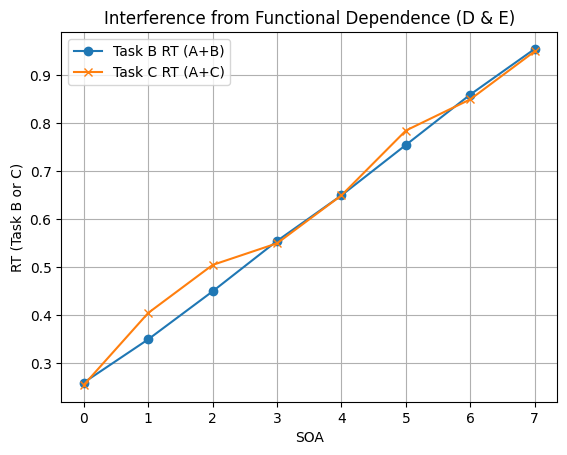

In [ ]:
# Plot RTS
plt.plot(results_ab["soa"], results_ab["rt_b"], label="Task B RT (A+B)", marker='o')
plt.plot(results_ac["soa"], results_ac["rt_b"], label="Task C RT (A+C)", marker='x')
plt.xlabel("SOA")
plt.ylabel("RT (Task B or C)")
plt.title("Interference from Functional Dependence (D & E)")
plt.grid(True)
plt.legend()
#plt.savefig("../output/plots/interference_functional_dependence.png", dpi=300)
plt.show()


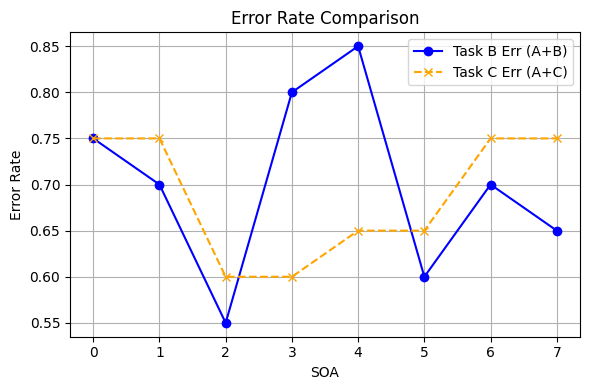

In [6]:
# Plot error rates
def plot_error_comparison(results_aX, results_aY, label_X="Task B Err (A+B)", label_Y="Task C Err (A+C)", title="Error Rate Comparison"):
    err_b_X = [1 - acc if not np.isnan(acc) else np.nan for acc in results_aX["acc_b"]]
    err_b_Y = [1 - acc if not np.isnan(acc) else np.nan for acc in results_aY["acc_b"]]

    plt.figure(figsize=(6, 4))
    plt.plot(results_aX["soa"], err_b_X, marker='o', color="blue", label=label_X)
    plt.plot(results_aY["soa"], err_b_Y, marker='x', color="orange", linestyle='--', label=label_Y)
    plt.xlabel("SOA")
    plt.ylabel("Error Rate")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

#plot
plot_error_comparison(results_ab, results_ac)


# Sim Study 3

## Training

In [2]:
# Train the model. Ideally use python scripts/train_model.py in terminal instead.

# Generate fixed task set A–E for training
inp, task, target, _ = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=100,
)

net = TaskNetworkWrapper(hidden_size=100)
net.train_online(inp, task, target, stop_loss=0.001) # Paper stop_loss = 0.001

# Save model after training
torch.save(net.model.state_dict(), "../output/trained_model_0001.pth")
print("✅ Model saved to output/trained_model.pth")


Epoch 000 | Loss: 1.5394 | Accuracy: 0.29
Epoch 010 | Loss: 0.0726 | Accuracy: 0.50
Epoch 020 | Loss: 0.0645 | Accuracy: 0.58
Epoch 030 | Loss: 0.0555 | Accuracy: 0.72
Epoch 040 | Loss: 0.0422 | Accuracy: 0.83
Epoch 050 | Loss: 0.0332 | Accuracy: 0.91
Epoch 060 | Loss: 0.0246 | Accuracy: 0.94
Epoch 070 | Loss: 0.0207 | Accuracy: 0.95
Epoch 080 | Loss: 0.0183 | Accuracy: 0.96
Epoch 090 | Loss: 0.0168 | Accuracy: 0.96
Epoch 100 | Loss: 0.0159 | Accuracy: 0.96
Epoch 110 | Loss: 0.0152 | Accuracy: 0.96
Epoch 120 | Loss: 0.0147 | Accuracy: 0.96
Epoch 130 | Loss: 0.0143 | Accuracy: 0.97
Epoch 140 | Loss: 0.0139 | Accuracy: 0.97
Epoch 150 | Loss: 0.0136 | Accuracy: 0.97
Epoch 160 | Loss: 0.0133 | Accuracy: 0.97
Epoch 170 | Loss: 0.0130 | Accuracy: 0.97
Epoch 180 | Loss: 0.0127 | Accuracy: 0.97
Epoch 190 | Loss: 0.0124 | Accuracy: 0.97
Epoch 200 | Loss: 0.0122 | Accuracy: 0.97
Epoch 210 | Loss: 0.0120 | Accuracy: 0.97
Epoch 220 | Loss: 0.0117 | Accuracy: 0.97
Epoch 230 | Loss: 0.0115 | Accurac

**Load trained model**

In [ ]:
# Load the trained model
# Initialize a fresh wrapper (same structure and hidden size)
net = TaskNetworkWrapper(hidden_size=100)

# Load saved weights into the internal model
net.model.load_state_dict(torch.load("../output/trained_model_00012.pth"))

# (Optional) Put in eval mode for inference
net.model.eval()

print("✅ Loaded trained model")

✅ Loaded trained model


### Training debug

In [5]:
# Single task trial testing

from prp.task_generator import generate_fixed_task_set

# Generate a small fixed single-task test set (same as training format)
input_sgl, tasks_sgl, train_sgl, meta = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=5,  # keep small for manual inspection
    seed=123
)

print(f"Testing on {len(input_sgl)} single-task inputs...")

# Test each pattern
for i in range(len(input_sgl)):
    s = input_sgl[i]
    t = tasks_sgl[i]
    y_true = train_sgl[i]

    y_pred = net.predict(s, t)

    print(f"Trial {i}")
    print(f"  Task: {meta['tasks_idx'][i]}")
    print(f"  True Argmax:     {np.argmax(y_true)}")
    print(f"  Predicted Argmax:{np.argmax(y_pred)}")
    print(f"  Output Vector:   {np.round(y_pred, 3)}\n")


Testing on 25 single-task inputs...
Trial 0
  Task: A
  True Argmax:     2
  Predicted Argmax:2
  Output Vector:   [ 0.031 -0.025  1.015 -0.024  0.082 -0.035  0.004  0.014  0.002]

Trial 1
  Task: A
  True Argmax:     2
  Predicted Argmax:2
  Output Vector:   [ 0.621 -0.481  0.872  0.416 -0.216 -0.184 -0.03   0.083 -0.038]

Trial 2
  Task: A
  True Argmax:     2
  Predicted Argmax:2
  Output Vector:   [ 0.045 -0.041  0.997  0.011  0.012 -0.022  0.006 -0.02   0.014]

Trial 3
  Task: A
  True Argmax:     1
  Predicted Argmax:1
  Output Vector:   [ 0.025  0.862  0.124  0.001  0.003  0.004  0.002  0.019 -0.01 ]

Trial 4
  Task: A
  True Argmax:     0
  Predicted Argmax:0
  Output Vector:   [ 0.933  0.012  0.044 -0.035  0.036 -0.009 -0.013  0.011 -0.01 ]

Trial 5
  Task: B
  True Argmax:     3
  Predicted Argmax:3
  Output Vector:   [ 0.02  -0.033  0.019  1.111  0.12  -0.23   0.004 -0.009  0.009]

Trial 6
  Task: B
  True Argmax:     4
  Predicted Argmax:4
  Output Vector:   [-0.018  0.013 

In [6]:
task_outputs = []
for i in range(len(input_sgl)):
    s = input_sgl[i]
    t = tasks_sgl[i]
    y = net.predict(s, t)
    task_outputs.append(np.argmax(y))

print("Output unit indices by task:", task_outputs)


Output unit indices by task: [np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(3), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(0), np.int64(6), np.int64(8), np.int64(8), np.int64(7), np.int64(3), np.int64(4), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(0), np.int64(0), np.int64(2), np.int64(2)]


In [9]:
# Multitask trial testing
from prp.task_generator import generate_fixed_task_set

# Generate single-task training-style patterns
input_sgl, task_sgl, target_sgl, meta = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=1,  # we just need 1 per task
    seed=999
)

# Task label → task vector lookup
label_to_index = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
task_idx_to_label = {v: k for k, v in label_to_index.items()}

# Get single-task samples
samples = {}
for i in range(len(input_sgl)):
    task_label = meta["tasks_idx"][i]
    samples[task_label] = {
        "stim": input_sgl[i],
        "task": task_sgl[i],
        "target": target_sgl[i]
    }

# Create multitask pairings (B + A and C + A)
for pair in [("B", "A"), ("C", "A")]:
    stim1 = samples[pair[0]]["stim"]
    task1 = samples[pair[0]]["task"]
    target1 = samples[pair[0]]["target"]

    stim2 = samples[pair[1]]["stim"]
    task2 = samples[pair[1]]["task"]
    target2 = samples[pair[1]]["target"]

    stim_combined = stim1 + stim2
    task_combined = task1 + task2
    target_combined = target1 + target2  # multiple output units active

    # Predict
    y_pred = net.predict(stim_combined, task_combined)

    # Top-k prediction indices
    top_k = y_pred.argsort()[-5:][::-1]  # top 5 predictions

    correct_indices = np.flatnonzero(target_combined)

    print(f"\nTesting multitask: {pair[0]} + {pair[1]}")
    print(f"  Correct Output Indices: {correct_indices}")
    print(f"  Top-5 Predicted Indices: {top_k}")
    print(f"  Output Vector: {np.round(y_pred, 3)}")

    hits = [idx for idx in correct_indices if idx in top_k]
    print(f"  Hits in Top-5: {hits} ({len(hits)}/{len(correct_indices)} correct)\n")



Testing multitask: B + A
  Correct Output Indices: [0 3]
  Top-5 Predicted Indices: [0 3 4 2 6]
  Output Vector: [ 0.774  0.144  0.349  0.702  0.363  0.19   0.332 -0.156  0.253]
  Hits in Top-5: [np.int64(0), np.int64(3)] (2/2 correct)


Testing multitask: C + A
  Correct Output Indices: [0 7]
  Top-5 Predicted Indices: [7 0 2 8 5]
  Output Vector: [0.871 0.061 0.439 0.012 0.108 0.224 0.097 1.197 0.245]
  Hits in Top-5: [np.int64(0), np.int64(7)] (2/2 correct)



### PRP simulation

In [6]:
# PRP simulator. Takes ~7 minutes to run with 10 trials pet SOA
# Efficient pairwise trial generator
def generate_trial_pair(prp_pair=("B", "A"), N_pathways=3, N_features=3, seed=None):
    """
    Generate a single PRP trial from a specific task pair (e.g., B → A).
    Only creates the required two tasks, unlike generate_fixed_task_set().
    """
    if seed is not None:
        np.random.seed(seed)

    task_map = {
        'A': (0, 0),
        'B': (1, 1),
        'C': (2, 2),
        'D': (0, 1),
        'E': (1, 0)
    }

    def sample_single_task(task_name):
        in_dim, out_dim = task_map[task_name]
        stim = np.zeros(N_pathways * N_features)
        features = np.random.randint(0, N_features, size=N_pathways)
        for i in range(N_pathways):
            stim[i * N_features + features[i]] = 1

        task_vec = np.zeros(N_pathways**2)
        task_vec[in_dim * N_pathways + out_dim] = 1

        target = np.zeros(N_pathways * N_features)
        target[out_dim * N_features + features[in_dim]] = 1

        return stim, task_vec, target

    stim1, task1, _ = sample_single_task(prp_pair[0])
    stim2, task2, _ = sample_single_task(prp_pair[1])
    return stim2, stim1, task2, task1 # Changed the order of stim1-2 and task1-2 to check if order is important


# ✅ Optional test calls
_ = generate_trial_pair(prp_pair=("B", "A"))
_ = generate_trial_pair(prp_pair=("C", "A"))


# ✅ Sweep for B → A (functionally dependent)
results_ba = sweep_soa(
    task_net=net,
    trial_generator=lambda: generate_trial_pair(("B", "A")),
    soa_values=list(range(0, 9)),  # SOAs 0–8
    n_trials_per_soa=10,           # Optional: increase to 50 for final experiments
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.9, # run with 0.9
    verbose=False
)

# ✅ Sweep for C → A (functionally independent)
results_ca = sweep_soa(
    task_net=net,
    trial_generator=lambda: generate_trial_pair(("C", "A")),
    soa_values=list(range(0, 9)),
    n_trials_per_soa=10,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.9, # 0.9 for proper interference.
    verbose=False
)

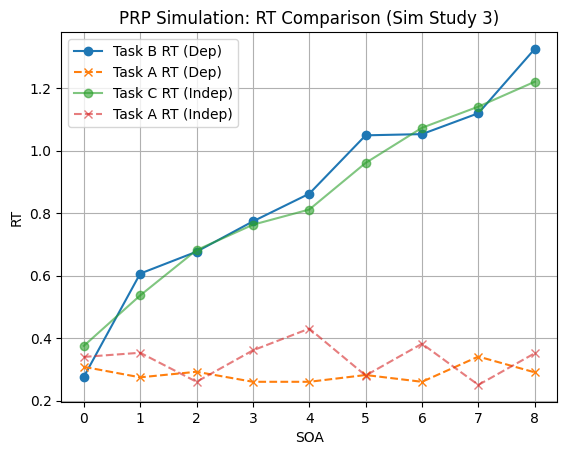

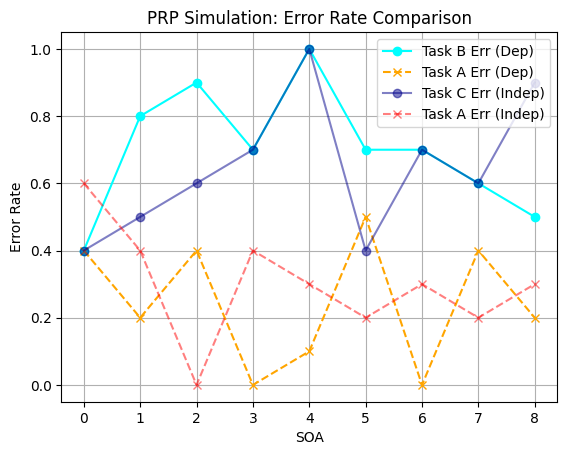

In [7]:
# Plot RTs and Error Rates

# RTs
plt.plot(results_ba["soa"], results_ba["rt_b"], label="Task B RT (Dep)", marker='o')
plt.plot(results_ba["soa"], results_ba["rt_a"], label="Task A RT (Dep)", marker='x', linestyle='--')

plt.plot(results_ca["soa"], results_ca["rt_b"], label="Task C RT (Indep)", marker='o', alpha=0.6)
plt.plot(results_ca["soa"], results_ca["rt_a"], label="Task A RT (Indep)", marker='x', linestyle='--', alpha=0.6)

plt.xlabel("SOA")
plt.ylabel("RT")
plt.title("PRP Simulation: RT Comparison (Sim Study 3)")
plt.grid(True)
plt.legend()
plt.savefig("../output/plots/prp_simulation_rt_comparison_order.png", dpi=300)
plt.show()

# Error Rates
err_a_ba = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_a"]]
err_b_ba = [1 - b if not np.isnan(b) else np.nan for b in results_ba["acc_b"]]
err_a_ca = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_a"]]
err_c_ca = [1 - b if not np.isnan(b) else np.nan for b in results_ca["acc_b"]]

plt.plot(results_ba["soa"], err_b_ba, marker='o', label="Task B Err (Dep)", color="cyan")
plt.plot(results_ba["soa"], err_a_ba, marker='x', linestyle='--', label="Task A Err (Dep)", color="orange")

plt.plot(results_ca["soa"], err_c_ca, marker='o', label="Task C Err (Indep)", color="darkblue", alpha=0.5)
plt.plot(results_ca["soa"], err_a_ca, marker='x', linestyle='--', label="Task A Err (Indep)", color="red", alpha=0.5)

plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rate Comparison")
plt.grid(True)
plt.legend()
plt.savefig("../output/plots/prp_simulation_ER_comparison_order.png", dpi=300)
plt.show()


#### Optimized LCA Threshold (Z)

In [ ]:
import numpy as np
from prp.lca import run_lca_avg  # or however you import it
# from prp.lca import optimize_lca_threshold  

def optimize_lca_threshold(input_series,
                           output_indices,
                           z_range=np.arange(0.6, 2.2, 0.1),
                           n_repeats=20,
                           ITI=0.5,
                           dt=0.1,
                           max_timesteps=100):
    """
    Finds the LCA threshold z that maximizes reward rate.

    Args:
        input_series: list of net input vectors to output layer
        output_indices: indices of output units relevant to task
        z_range: range of threshold values to test
        n_repeats: number of LCA runs per threshold
        ITI: inter-trial interval
        dt: timestep duration
        max_timesteps: max steps for LCA

    Returns:
        best_z: threshold value maximizing reward rate
        results: dict of {z: (accuracy, RT, reward_rate)}
    """
    results = {}

    for z in z_range:
        rts = []
        corrects = 0

        for _ in range(n_repeats):
            rt, choice = run_lca_avg(
                input_series=input_series,
                relevant_output_indices=output_indices,
                threshold=z,
                n_repeats=1,
                max_timesteps=max_timesteps,
                dt=dt
            )

            if rt is None:
                continue  # LCA failed to decide

            # Simulate a correct response (we assume correct unit is always max input)
            target_idx = np.argmax([input_series[0][i] for i in output_indices])
            corrects += int(choice == output_indices[target_idx])
            rts.append(rt)

        if len(rts) == 0:
            avg_rt = np.nan
            acc = 0.0
        else:
            avg_rt = np.mean(rts)
            acc = corrects / len(rts)

        reward_rate = acc / (ITI + avg_rt) if avg_rt else 0.0
        results[z] = (acc, avg_rt, reward_rate)

    best_z = max(results.items(), key=lambda x: x[1][2])[0]
    return best_z, results


In [14]:
from prp.task_generator import generate_fixed_task_set

# Grab a single sample for Task B
inputs, tasks, targets, meta = generate_fixed_task_set(samples_per_task=1)
for i, label in enumerate(meta["tasks_idx"]):
    if label == "B":
        stim_b = inputs[i]
        task_b = tasks[i]
        break


In [15]:
output_series = net.get_output_net_input_series(
    input_series=[stim_b] * 3,  # 3 time steps with static input
    task_series=[task_b] * 3,
    tau_net=0.2,
    tau_task=0.2,
    persistence=0.5
)


In [16]:
best_z, all_results = optimize_lca_threshold(
    input_series=output_series,
    output_indices=[3, 4, 5],  # Task B’s output units
    z_range=np.arange(0.6, 2.2, 0.1),
    n_repeats=20
)

print(f"✅ Best threshold z: {best_z}")
for z, (acc, rt, rr) in all_results.items():
    print(f"z={z:.2f} | Acc={acc:.2f} | RT={rt:.3f} | RewardRate={rr:.3f}")


✅ Best threshold z: 0.6
z=0.60 | Acc=0.00 | RT=0.250 | RewardRate=0.000
z=0.70 | Acc=0.00 | RT=0.250 | RewardRate=0.000
z=0.80 | Acc=0.00 | RT=0.250 | RewardRate=0.000
z=0.90 | Acc=0.00 | RT=0.250 | RewardRate=0.000
z=1.00 | Acc=0.00 | RT=0.280 | RewardRate=0.000
z=1.10 | Acc=0.00 | RT=0.350 | RewardRate=0.000
z=1.20 | Acc=0.00 | RT=0.350 | RewardRate=0.000
z=1.30 | Acc=0.00 | RT=0.350 | RewardRate=0.000
z=1.40 | Acc=0.00 | RT=0.350 | RewardRate=0.000
z=1.50 | Acc=0.00 | RT=0.350 | RewardRate=0.000
z=1.60 | Acc=0.00 | RT=nan | RewardRate=nan
z=1.70 | Acc=0.00 | RT=nan | RewardRate=nan
z=1.80 | Acc=0.00 | RT=nan | RewardRate=nan
z=1.90 | Acc=0.00 | RT=nan | RewardRate=nan
z=2.00 | Acc=0.00 | RT=nan | RewardRate=nan
z=2.10 | Acc=0.00 | RT=nan | RewardRate=nan


## Diagnostics

### Network Behavior

In [20]:
# Task similarity matrix computation
from collections import defaultdict

def get_mean_hidden_activations(task_net, stim_inputs, task_inputs, task_ids, tau_net=1.0):
    hidden_by_task = defaultdict(list)

    for stim, task, task_id in zip(stim_inputs, task_inputs, task_ids):
        stim_t = torch.tensor(stim, dtype=torch.float32)
        task_t = torch.tensor(task, dtype=torch.float32)

        with torch.no_grad():
            x = torch.cat((stim_t, task_t))
            net_hidden = task_net.model.fc_input_to_hidden(x) + tau_net * task_net.model.task_to_hidden(task_t) - 2.0
            h = task_net.model.activation_fn(net_hidden)
            hidden_by_task[int(task_id)].append(h.detach().numpy())

    return {task_id: np.mean(hs, axis=0) for task_id, hs in hidden_by_task.items()}

def compute_task_similarity_matrix(mean_hidden):
    task_ids = sorted(mean_hidden.keys())
    activations = np.stack([mean_hidden[tid] for tid in task_ids])
    corr_matrix = np.corrcoef(activations)
    return task_ids, corr_matrix


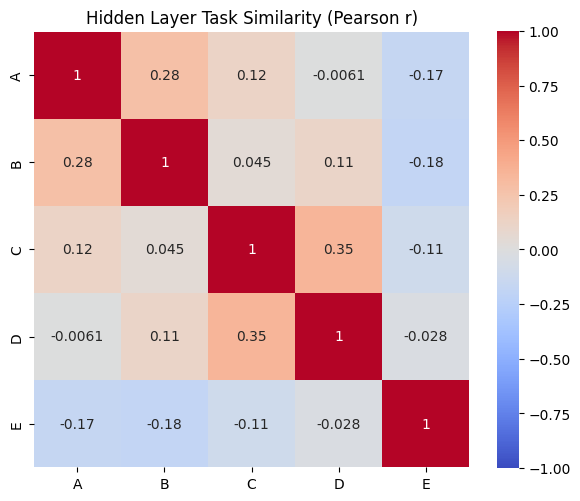

In [21]:
# If your task array is one-hot encoded: shape (N_trials, N_tasks)
# Get the index of the active task unit for each trial
task_ids_int = [int(np.argmax(t)) for t in task]

# Compute mean hidden activations per task
mean_hidden = get_mean_hidden_activations(
    task_net=net,
    stim_inputs=inp,
    task_inputs=task,
    task_ids=task_ids_int,
    tau_net=1.0  # adjust if needed
)

# Compute similarity matrix
task_ids_sorted, corr_matrix = compute_task_similarity_matrix(mean_hidden)

# Plot as Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

task_labels = ['A', 'B', 'C', 'D', 'E']  # You can adjust this if needed
df = pd.DataFrame(corr_matrix, index=task_labels, columns=task_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Hidden Layer Task Similarity (Pearson r)")
plt.tight_layout()
plt.show()



Cumulative RT Distribution

In [ ]:

def collect_prp_rts(task_net, prp_pair=("B", "A"), soa=0, n_repeats=200, **kwargs):
    rts_task1 = []
    rts_task2 = []

    for _ in range(n_repeats):
        s1, s2, t1, t2 = simple_trial_generator(prp_pair)
        rt1, _, rt2, _, _ = run_prp_trial(
            task_net, s1, s2, t1, t2, soa=soa, **kwargs
        )
        if rt1 is not None and rt2 is not None:
            rts_task1.append(rt1)
            rts_task2.append(rt2)

    return np.array(rts_task1), np.array(rts_task2)



def plot_cumulative_rt(rt1, rt2, label1="Task 1", label2="Task 2", color1="blue", color2="orange"):
    plt.figure(figsize=(6, 4))
    sorted1 = np.sort(rt1)
    sorted2 = np.sort(rt2)
    cum1 = np.linspace(0, 1, len(sorted1))
    cum2 = np.linspace(0, 1, len(sorted2))

    plt.plot(sorted1, cum1, label=label1, color=color1)
    plt.plot(sorted2, cum2, label=label2, color=color2)

    plt.xlabel("RT")
    plt.ylabel("Cumulative Probability")
    plt.title("Cumulative RT Distributions")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    #plt.savefig("../output/plots/cumulative_rt_comparison.png", dpi=300)
    plt.show()



rts_b, rts_a_b = collect_prp_rts(net, prp_pair=("B", "A"), soa=2, n_repeats=300)
rts_c, rts_a_c = collect_prp_rts(net, prp_pair=("C", "A"), soa=2, n_repeats=300)

# Plot cumulative RT for Task A in both cases
plot_cumulative_rt(rts_a_b, rts_a_c, label1="Task A (B→A)", label2="Task A (C→A)")


KeyboardInterrupt: 

## Debugging

### LCA

In [ ]:
# Inspect output net inputs
for t, vec in enumerate(output_series):
    print(f"t={t} | Output Net Input: {np.round(vec, 3)}")


In [ ]:
from prp.lca import run_lca_avg

# Assume Task B sample from earlier
output_series = net.get_output_net_input_series([stim_b]*10, [task_b]*10)

# Task B output indices
output_idx = [3, 4, 5]

# Try a low threshold to ensure it responds
rt, choice = run_lca_avg(
    input_series=output_series,
    relevant_output_indices=output_idx,
    n_repeats=1,
    threshold=0.7,
    max_timesteps=100
)

print(f"RT: {rt}, Choice: {choice}, Correct: {choice in output_idx}")


In [ ]:
import numpy as np

def debug_lca_run(input_series, relevant_output_indices, threshold=1.0,
                  dt=0.1, lambda_=0.4, alpha=0.2, beta=0.2,
                  noise_std=0.2, t0=0.15, max_timesteps=100):
    """
    Debugging version of LCA: logs accumulation trace and drift values.
    """
    n_units = len(relevant_output_indices)
    acc = np.zeros(n_units)
    noise = lambda: np.random.normal(0, noise_std, size=n_units)

    print(f"🧪 Starting LCA run | Threshold: {threshold} | Units: {relevant_output_indices}\n")

    for t in range(max_timesteps):
        input_t = input_series[t]
        drift_input = np.array([input_t[i] for i in relevant_output_indices])

        # LCA update rule
        competition = lambda_ * (np.sum(acc) - acc)
        leakage = alpha * acc
        noise_t = noise()

        dx = drift_input - competition - leakage + noise_t
        acc += dt * dx
        acc = np.clip(acc, 0, None)  # no negative activations

        # Logging
        print(f"t={t} | Drift: {np.round(drift_input, 3)} | Δ: {np.round(dx, 3)} | Acc: {np.round(acc, 3)}")

        # Threshold check
        if np.any(acc >= threshold):
            winner = np.argmax(acc)
            print(f"\n✅ Threshold reached at t={t} | Choice: {winner} | RT: {round(t*dt + t0, 3)}s\n")
            return t*dt + t0, relevant_output_indices[winner]

    print("\n❌ LCA failed to reach threshold within max_timesteps.\n")
    return None, None

# For Task B output units [3, 4, 5]
output_series = net.get_output_net_input_series([stim_b]*20, [task_b]*20)

rt, choice = debug_lca_run(
    input_series=output_series,
    relevant_output_indices=[3, 4, 5],  # adjust based on task
    threshold=1.0,
    max_timesteps=20
)

